01 — Data Inspection

**Purpose:** Load the Telco Customer Churn dataset and understand
its structure before any cleaning or modeling.

**Dataset:** data/raw/telco_customer_churn.csv

In [ ]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

In [ ]:
DATA_PATH = "../data/raw/telco_customer_churn.csv"

df = pd.read_csv(DATA_PATH)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values detected by pandas.")
else:
    print("Missing values per column:")
    print(missing)

In [ ]:
blank_total_charges = (df["TotalCharges"].astype(str).str.strip() == "").sum()

print("Blank TotalCharges entries:", blank_total_charges)
print("TotalCharges dtype:", df["TotalCharges"].dtype)

In [ ]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)

print()
print("Churn percentage:")
print(churn_pct.round(2))

In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical columns:", len(categorical_cols))
print()

for col in categorical_cols:
    unique_vals = df[col].nunique()
    print(f"{col:25s} → {unique_vals} unique values")

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Numeric columns:", list(numeric_cols))
print()

for col in numeric_cols:
    print(
        f"{col:20s} "
        f"min={df[col].min()}   "
        f"max={df[col].max()}   "
        f"mean={df[col].mean():.2f}"
    )

## Day 2 — Findings Summary

**Dataset shape:** 7,043 rows × 21 columns.

**Target column:** `Churn` (Yes / No), currently stored as text.

**Class distribution:** Imbalanced — approximately 26–27% of
customers churned. This must be considered when choosing
evaluation metrics later.

**Data quality issues found so far:**

1. `TotalCharges` is stored as text (`object`) instead of a number.
2. `TotalCharges` contains a small number of blank entries that
   pandas does not detect as missing values.
3. `customerID` is a unique identifier with no predictive value
   and should be removed before modeling.
4. `Churn` needs to be converted from Yes/No text to 1/0 for
   machine learning.

**Next step (Day 3):** Clean the dataset — fix data types, handle
blanks, drop the ID column, and save a cleaned copy to
`data/processed/`.

---
## Day 3 — Data Cleaning
---

In [ ]:
import pandas as pd
import numpy as np

# Load the raw dataset fresh for cleaning
df = pd.read_csv("../data/raw/telco_customer_churn.csv")

print("Shape before cleaning:", df.shape)
df.head(3)

In [ ]:
# Check all column types before cleaning
df.dtypes

In [ ]:
# Find rows where TotalCharges is blank
blank_mask = df["TotalCharges"].astype(str).str.strip() == ""

print("Number of blank TotalCharges rows:", blank_mask.sum())
print()
print("The rows with blank TotalCharges:")
df[blank_mask][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

In [ ]:
# Step 1: Replace blank spaces with NaN
df["TotalCharges"] = df["TotalCharges"].str.strip()
df["TotalCharges"] = df["TotalCharges"].replace("", np.nan)

# Step 2: Convert to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Step 3: Fill the 11 blank values with 0.0
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# Verify
print("TotalCharges dtype after fix:", df["TotalCharges"].dtype)
print("Remaining NaN in TotalCharges:", df["TotalCharges"].isnull().sum())

In [ ]:
print("Before conversion:")
print(df["Churn"].value_counts())
print("Dtype:", df["Churn"].dtype)

In [ ]:
# Convert Churn: Yes → 1, No → 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Verify
print("After conversion:")
print(df["Churn"].value_counts())
print("Dtype:", df["Churn"].dtype)

In [ ]:
# Drop customerID - it is an identifier, not a feature
print("Columns before drop:", df.shape[1])

df = df.drop(columns=["customerID"])

print("Columns after drop:", df.shape[1])
print("customerID still in df:", "customerID" in df.columns)

In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

In [ ]:
# Inspect the duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicate_rows))
duplicate_rows.head(30)

In [ ]:
# Check how many duplicate groups there are
print("Duplicate rows excluding first occurrence:", df.duplicated().sum())
print("Number of completely duplicated records:", df.duplicated(keep=False).sum())

In [ ]:
# Remove duplicate rows, keeping the first occurrence
before = df.shape[0]

df = df.drop_duplicates()

after = df.shape[0]

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Rows removed:", before - after)

In [ ]:
print("Remaining duplicate rows:", df.duplicated().sum())

In [ ]:
# Final missing value check after cleaning
missing = df.isnull().sum()

print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

In [ ]:
# Final shape check
print("Final cleaned shape:", df.shape)
print()

print("Column data types:")
print(df.dtypes)

In [ ]:
# Preview the clean dataset
df.head(5)

In [ ]:
# Check basic statistics for numeric columns
df.describe()

In [ ]:
import os

# Make sure the processed folder exists
os.makedirs("../data/processed", exist_ok=True)

# Save the cleaned dataset
output_path = "../data/processed/cleaned_churn_data.csv"
df.to_csv(output_path, index=False)

print("Cleaned dataset saved to:", output_path)

# Verify it was saved correctly by reloading
df_check = pd.read_csv(output_path)

print("Rows:", df_check.shape[0])
print("Columns:", df_check.shape[1])
print("TotalCharges dtype in saved file:", df_check["TotalCharges"].dtype)
print("Churn dtype in saved file:", df_check["Churn"].dtype)

# Day 4 — Exploratory Data Analysis

## Objectives

- Create a reproducible train-test split.
- Keep the test data untouched.
- Analyze churn distribution.
- Analyze churn by contract type.
- Compare tenure between churned and non-churned customers.
- Compare monthly charges between churned and non-churned customers.
- Save the figures for the project report and README.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
current_directory = Path.cwd()

if (current_directory / "data").exists():
    PROJECT_ROOT = current_directory
elif (current_directory.parent / "data").exists():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError(
        "Project root could not be found. "
        "Open the customer-churn-retention-engine folder in VS Code."
    )

CLEANED_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "cleaned_churn_data.csv"
)

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned data:", CLEANED_DATA_PATH)
print("Figures folder:", FIGURES_DIR)

Project root: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine
Cleaned data: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\data\processed\cleaned_churn_data.csv
Figures folder: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures


In [3]:
df = pd.read_csv(CLEANED_DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
required_columns = {
    "Churn",
    "Contract",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

assert df["Churn"].notna().all(), "Churn contains missing values."

assert set(df["Churn"].unique()).issubset({0, 1}), (
    "Churn must contain only 0 and 1."
)

assert pd.api.types.is_numeric_dtype(df["TotalCharges"]), (
    "TotalCharges must be numeric."
)

print("Dataset validation passed.")
print("Churn values:", sorted(df["Churn"].unique()))

Dataset validation passed.
Churn values: [np.int64(0), np.int64(1)]


In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Churn"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Full dataset:", df.shape)
print("Training dataset:", train_df.shape)
print("Test dataset:", test_df.shape)

Full dataset: (7021, 20)
Training dataset: (5616, 20)
Test dataset: (1405, 20)


In [8]:
split_comparison = pd.DataFrame({
    "Dataset": ["Full", "Training", "Test"],
    "Rows": [
        len(df),
        len(train_df),
        len(test_df)
    ],
    "Churn Rate (%)": [
        df["Churn"].mean() * 100,
        train_df["Churn"].mean() * 100,
        test_df["Churn"].mean() * 100
    ]
})

split_comparison["Churn Rate (%)"] = (
    split_comparison["Churn Rate (%)"].round(2)
)

split_comparison

,Dataset,Rows,Churn Rate (%)
0,Full,7021,26.45
1,Training,5616,26.44
2,Test,1405,26.48


In [9]:
train_data_path = PROCESSED_DATA_DIR / "train_churn_data.csv"
test_data_path = PROCESSED_DATA_DIR / "test_churn_data.csv"

train_df.to_csv(train_data_path, index=False)
test_df.to_csv(test_data_path, index=False)

print("Training data saved to:", train_data_path)
print("Test data saved to:", test_data_path)

Training data saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\data\processed\train_churn_data.csv
Test data saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\data\processed\test_churn_data.csv


In [10]:
eda_df = train_df.copy()

eda_df["ChurnLabel"] = eda_df["Churn"].map({
    0: "Stayed",
    1: "Churned"
})

print("EDA dataset shape:", eda_df.shape)
eda_df.head()

EDA dataset shape: (5616, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnLabel
0,Male,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,No,Credit card (automatic),70.70,140.70,1,Churned
1,Female,0,No,No,15,Yes,Yes,Fiber optic,Yes,No,...,No,No,No,Month-to-month,Yes,Credit card (automatic),84.35,1302.65,0,Stayed
2,Male,0,Yes,Yes,67,Yes,Yes,Fiber optic,No,Yes,...,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),89.55,6373.10,0,Stayed
3,Male,0,No,No,5,Yes,No,DSL,No,Yes,...,Yes,No,Yes,Month-to-month,Yes,Bank transfer (automatic),65.60,339.90,0,Stayed
4,Male,0,No,No,26,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,20.30,511.25,0,Stayed


In [11]:
sns.set_theme(style="whitegrid")

CHURN_COLORS = {
    "Stayed": "#4C78A8",
    "Churned": "#E45756"
}

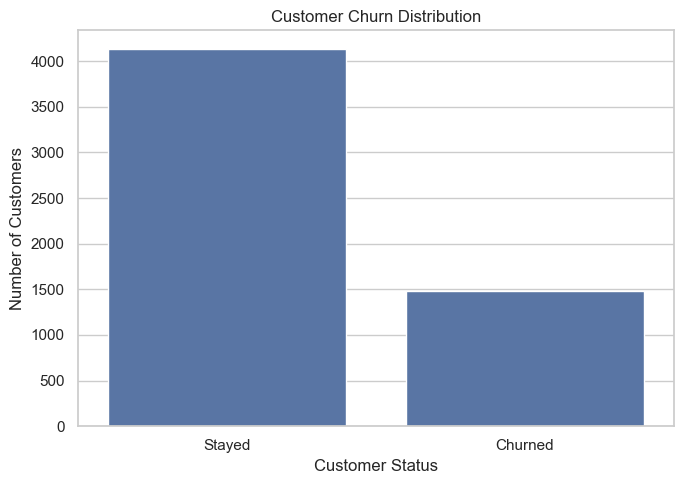

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\01_churn_distribution.png


In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="ChurnLabel",
    order=["Stayed", "Churned"]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()

chart_path = FIGURES_DIR / "01_churn_distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

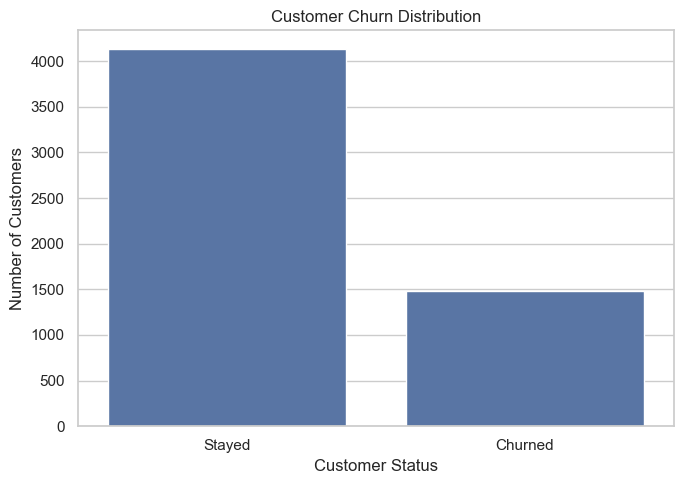

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\01_churn_distribution.png


In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="ChurnLabel",
    order=["Stayed", "Churned"]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()

chart_path = FIGURES_DIR / "01_churn_distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_summary,
    x="Contract",
    y="Churn Rate (%)"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()

chart_path = FIGURES_DIR / "02_contract_churn_rate.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

NameError: name 'contract_summary' is not defined

<Figure size 800x500 with 0 Axes>

In [15]:
tenure_summary = (
    eda_df.groupby("ChurnLabel")["tenure"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

tenure_summary["mean"] = tenure_summary["mean"].round(2)
tenure_summary["median"] = tenure_summary["median"].round(2)

tenure_summary

,ChurnLabel,count,mean,median
0,Churned,1485,18.35,10.0
1,Stayed,4131,37.50,37.0


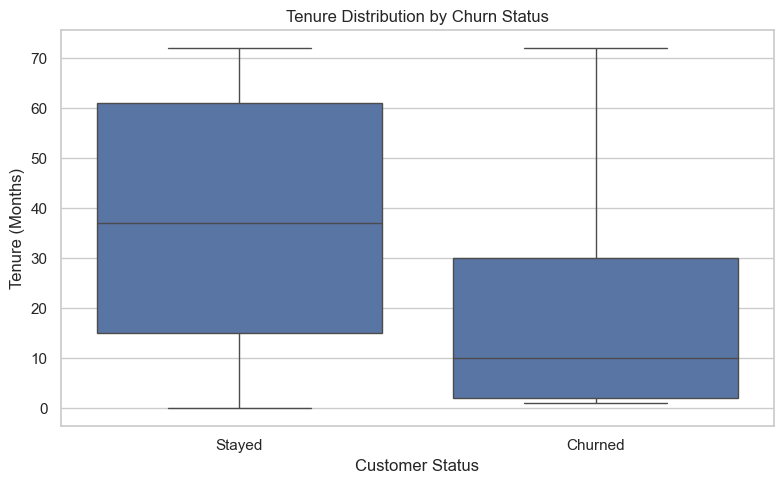

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\03_tenure_vs_churn.png


In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=eda_df,
    x="ChurnLabel",
    y="tenure",
    order=["Stayed", "Churned"]
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Tenure (Months)")
plt.tight_layout()

chart_path = FIGURES_DIR / "03_tenure_vs_churn.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

In [17]:
monthly_charges_summary = (
    eda_df.groupby("ChurnLabel")["MonthlyCharges"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

monthly_charges_summary["mean"] = (
    monthly_charges_summary["mean"].round(2)
)

monthly_charges_summary["median"] = (
    monthly_charges_summary["median"].round(2)
)

monthly_charges_summary

,ChurnLabel,count,mean,median
0,Churned,1485,75.13,79.9
1,Stayed,4131,61.22,64.5


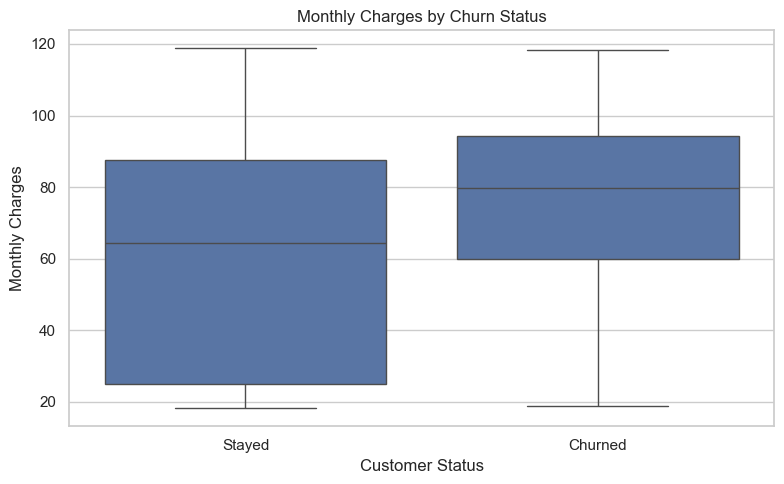

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\04_monthly_charges_vs_churn.png


In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=eda_df,
    x="ChurnLabel",
    y="MonthlyCharges",
    order=["Stayed", "Churned"]
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")
plt.tight_layout()

chart_path = FIGURES_DIR / "04_monthly_charges_vs_churn.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

In [19]:
target_summary = (
    eda_df["ChurnLabel"]
    .value_counts()
    .rename_axis("Churn Status")
    .reset_index(name="Customers")
)

target_summary["Percentage (%)"] = (
    target_summary["Customers"] / len(eda_df) * 100
).round(2)

target_summary

,Churn Status,Customers,Percentage (%)
0,Stayed,4131,73.56
1,Churned,1485,26.44


In [22]:

# 1. Target summary
target_summary = (
    eda_df["ChurnLabel"]
    .value_counts()
    .rename_axis("Churn Status")
    .reset_index(name="Customers")
)

target_summary["Percentage (%)"] = (
    target_summary["Customers"] / len(eda_df) * 100
).round(2)


# 2. Contract summary
contract_summary = (
    eda_df.groupby("Contract")["Churn"]
    .agg(["count", "mean"])
    .reset_index()
)

contract_summary["Churn Rate (%)"] = (
    contract_summary["mean"] * 100
).round(2)

contract_summary = contract_summary.drop(columns="mean")


# 3. Tenure summary
tenure_summary = (
    eda_df.groupby("ChurnLabel")["tenure"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

tenure_summary["mean"] = tenure_summary["mean"].round(2)
tenure_summary["median"] = tenure_summary["median"].round(2)


# 4. Monthly charges summary
monthly_charges_summary = (
    eda_df.groupby("ChurnLabel")["MonthlyCharges"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

monthly_charges_summary["mean"] = (
    monthly_charges_summary["mean"].round(2)
)

monthly_charges_summary["median"] = (
    monthly_charges_summary["median"].round(2)
)


# 5. Save summaries
target_summary.to_csv(
    REPORTS_DIR / "day4_target_summary.csv",
    index=False
)

contract_summary.to_csv(
    REPORTS_DIR / "day4_contract_summary.csv",
    index=False
)

tenure_summary.to_csv(
    REPORTS_DIR / "day4_tenure_summary.csv",
    index=False
)

monthly_charges_summary.to_csv(
    REPORTS_DIR / "day4_monthly_charges_summary.csv",
    index=False
)

split_comparison.to_csv(
    REPORTS_DIR / "day4_split_summary.csv",
    index=False
)

print("All Day 4 summary files saved successfully.")

All Day 4 summary files saved successfully.


In [27]:
print("TARGET SUMMARY")
display(target_summary)

print("\nCONTRACT SUMMARY")
display(contract_summary)

print("\nTENURE SUMMARY")
display(tenure_summary)

print("\nMONTHLY CHARGES SUMMARY")
display(monthly_charges_summary)

print("\nSPLIT SUMMARY")
display(split_comparison)

TARGET SUMMARY


,Churn Status,Customers,Percentage (%)
0,Stayed,4131,73.56
1,Churned,1485,26.44



CONTRACT SUMMARY


,Contract,count,Churn Rate (%)
0,Month-to-month,3078,42.66
1,One year,1182,11.17
2,Two year,1356,2.95



TENURE SUMMARY


,ChurnLabel,count,mean,median
0,Churned,1485,18.35,10.0
1,Stayed,4131,37.50,37.0



MONTHLY CHARGES SUMMARY


,ChurnLabel,count,mean,median
0,Churned,1485,75.13,79.9
1,Stayed,4131,61.22,64.5



SPLIT SUMMARY


,Dataset,Rows,Churn Rate (%)
0,Full,7021,26.45
1,Training,5616,26.44
2,Test,1405,26.48


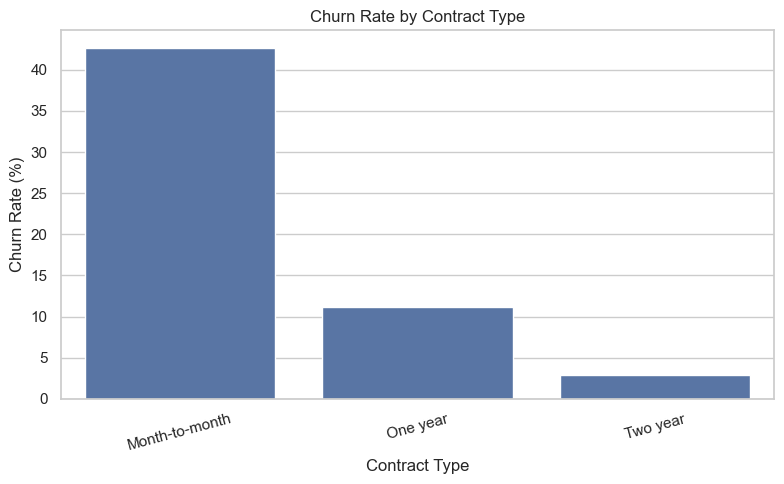

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\02_contract_churn_rate.png


In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_summary,
    x="Contract",
    y="Churn Rate (%)"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()

chart_path = FIGURES_DIR / "02_contract_churn_rate.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

In [26]:
# Verify all Day 4 charts
expected_charts = [
    "01_churn_distribution.png",
    "02_contract_churn_rate.png",
    "03_tenure_vs_churn.png",
    "04_monthly_charges_vs_churn.png"
]

print("DAY 4 CHART CHECK")
print("-" * 40)

for chart in expected_charts:
    path = FIGURES_DIR / chart
    print("✓" if path.exists() else "✗", chart)


# Verify summary files
expected_reports = [
    "day4_target_summary.csv",
    "day4_contract_summary.csv",
    "day4_tenure_summary.csv",
    "day4_monthly_charges_summary.csv",
    "day4_split_summary.csv"
]

print("\nDAY 4 SUMMARY FILE CHECK")
print("-" * 40)

for report in expected_reports:
    path = REPORTS_DIR / report
    print("✓" if path.exists() else "✗", report)

DAY 4 CHART CHECK
----------------------------------------
✓ 01_churn_distribution.png
✓ 02_contract_churn_rate.png
✓ 03_tenure_vs_churn.png
✓ 04_monthly_charges_vs_churn.png

DAY 4 SUMMARY FILE CHECK
----------------------------------------
✓ day4_target_summary.csv
✓ day4_contract_summary.csv
✓ day4_tenure_summary.csv
✓ day4_monthly_charges_summary.csv
✓ day4_split_summary.csv
